In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.preprocessing import StandardScaler,MinMaxScaler

In [2]:
df=pd.read_csv('iris.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


In [3]:
df.sample(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
125,7.2,3.2,6.0,1.8,Iris-virginica
71,6.1,2.8,4.0,1.3,Iris-versicolor
50,7.0,3.2,4.7,1.4,Iris-versicolor
25,5.0,3.0,1.6,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa


In [4]:
print(df.isnull().sum())

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [5]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
#Split the df into training set and testing set

X=df.drop(columns=['Species'])
y=df['Species']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
X_train.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,120.000000,120.000000,120.000000,120.000000
mean,5.809167,3.057500,3.727500,1.182500
std,0.823805,0.446398,1.751252,0.753442
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.500000,0.300000
50%,5.750000,3.000000,4.250000,1.300000
75%,6.400000,3.325000,5.100000,1.800000
max,7.700000,4.400000,6.700000,2.500000


In [10]:
standard_scaler=StandardScaler()
X_train=standard_scaler.fit_transform(X_train)
X_test=standard_scaler.transform(X_test)

In [13]:
X_train[:10]

array([[-1.47393679,  1.22037928, -1.5639872 , -1.30948358],
       [-0.13307079,  3.02001693, -1.27728011, -1.04292204],
       [ 1.08589829,  0.09560575,  0.38562104,  0.28988568],
       [-1.23014297,  0.77046987, -1.21993869, -1.30948358],
       [-1.7177306 ,  0.32056046, -1.39196294, -1.30948358],
       [ 0.59831066, -1.25412249,  0.72966956,  0.95628954],
       [ 0.72020757,  0.32056046,  0.44296246,  0.42316645],
       [-0.74255534,  0.99542457, -1.27728011, -1.30948358],
       [-0.98634915,  1.22037928, -1.33462153, -1.30948358],
       [-0.74255534,  2.34515281, -1.27728011, -1.44276436]])

In [ ]:
print(f'Mean={np.mean(X_train)}')
print(f"Standard Deviation={np.std(X_train)}")

Mean=4.357625371653739e-16
Standard Deviation=1.0


In [16]:
#Initialize a KNN Classifier
knn_model=KNeighborsClassifier(n_neighbors=5)
# Train the model
knn_model.fit(X_train,y_train)
#Get the predictions from the model
knn_preds=knn_model.predict(X_test)
#Compute the accuracy
acc_score=accuracy_score(y_true=y_test,y_pred=knn_preds)*100
print(f"The accuracy is {acc_score:.2f}%")

The accuracy is 100.00%


In [17]:
#Compute the confusion matrix

confusion_matrix=confusion_matrix(y_true=y_test,y_pred=knn_preds)
print(f'Confusion Matrix:\n{confusion_matrix}')

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [20]:
#Compute the classification report
classification_report=classification_report(y_true=y_test,y_pred=knn_preds)
print(f'Classification Report:\n{classification_report}')

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [24]:
species_list=df['Species'].unique()
print(species_list)

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


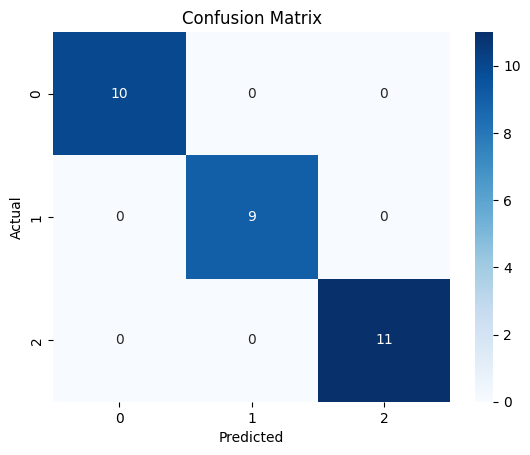

In [22]:
#Plot the confusion matrix

plt.Figure(figsize=(8,6))
sns.heatmap(confusion_matrix,annot=True,fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
